In [2]:
# pip install torch torchvision scikit-learn matplotlib pillow tqdm seaborn pandas opencv-python
import os, time, copy, json, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    torch.backends.cudnn.benchmark = True          # faster for fixed 224x224 inputs
    torch.backends.cudnn.deterministic = False
    torch.backends.cuda.matmul.allow_tf32 = True   # faster on RTX 30/40-series GPUs
    torch.backends.cudnn.allow_tf32 = True
else:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Mixed precision (faster and uses less GPU memory)
use_amp = device.type == "cuda"
try:
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
print("Mixed precision (AMP):", use_amp)

Device: cuda
GPU: GeForce GTX 1650
GPU memory: 4.0 GB
Mixed precision (AMP): True


In [3]:
# 2. Load data (train is already pre-augmented offline, so live augmentation is moderate)
from collections import Counter

data_dir = Path(r"D:\Farm AI Dataset Final\Farm AI Dataset Final")
img_height, img_width = 224, 224
batch_size = 32
num_workers = 0   # keep 0 on Windows/Jupyter to avoid hangs

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop((img_height, img_width), scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random"),
])

val_tfms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(data_dir / "train", transform=train_tfms)
val_ds   = datasets.ImageFolder(data_dir / "val",   transform=val_tfms)
test_ds  = datasets.ImageFolder(data_dir / "test",  transform=val_tfms)

assert train_ds.classes == val_ds.classes == test_ds.classes, "Class folders differ between train/val/test!"

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

tc, vc, sc = Counter(train_ds.targets), Counter(val_ds.targets), Counter(test_ds.targets)
print(f"\n{'Class':<40}{'Train':>7}{'Val':>7}{'Test':>7}")
for i, cls in enumerate(class_names):
    print(f"{cls:<40}{tc[i]:>7}{vc[i]:>7}{sc[i]:>7}")
print(f"\nTotal -> Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

pin = device.type == "cuda"
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)

Number of classes: 25

Class                                     Train    Val   Test
Anthracnose Redrot Sorghum                  700    122    124
Bacterialblight Cotton                      700    127    128
Bacterialblight rice                        700    138    138
Brownrust Sugarcane                         700    112    113
Brownspot rice                              700    124    125
Brownstreak Cassava                         700    150    150
Commonrust corn                             700    126    126
Earlyleafspot Groundnut                     700    120    120
Grayleafspot Coconut                        700    150    150
Grayspot corn                               700    105    106
Healthy Cassava                             700    150    150
Healthy Cotton                              700    134    136
Healthy Groundnut                           700    120    120
Healthy Sugarcane                           700    120    120
Healthy corn                                700

In [4]:
# 3. Build MobileNetV3-Large
UNFREEZE_FROM = 10   # features[10:] trainable. Lower number = more layers unfrozen.

model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)

for param in model.features.parameters():
    param.requires_grad = False
for block in model.features[UNFREEZE_FROM:]:
    for param in block.parameters():
        param.requires_grad = True

in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, num_classes)

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Model ready on {device} | classes: {num_classes} | trainable params: {trainable:,} / {total:,}")

Model ready on cuda | classes: 25 | trainable params: 4,074,105 / 4,234,057


In [6]:
# 4. Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

backbone_params = [p for p in model.features.parameters() if p.requires_grad]
head_params = list(model.classifier.parameters())

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": 1e-4},   # pretrained layers -> small LR
    {"params": head_params,     "lr": 1e-3},   # new head -> larger LR
], weight_decay=1e-4)

scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
grad_clip_value = 2.0


Epoch 1/30 | LR backbone: 0.000100 | LR head: 0.001000


train Loss: 1.7251  Acc: 0.6376


val   Loss: 0.9866  Acc: 0.8779
  ✅ Best model saved
Epoch time: 537s

Epoch 2/30 | LR backbone: 0.000100 | LR head: 0.001000


train Loss: 1.5423  Acc: 0.7151


val   Loss: 0.9182  Acc: 0.9066
  ✅ Best model saved
Epoch time: 364s

Epoch 3/30 | LR backbone: 0.000100 | LR head: 0.001000


...

val   Loss: 0.7809  Acc: 0.9507
Epoch time: 345s

Epoch 24/30 | LR backbone: 0.000006 | LR head: 0.000063


train Loss: 1.2115  Acc: 0.8211


val   Loss: 0.7670  Acc: 0.9535
Epoch time: 347s

Epoch 25/30 | LR backbone: 0.000006 | LR head: 0.000063


train Loss: 1.1907  Acc: 0.8314


val   Loss: 0.7751  Acc: 0.9525
Epoch time: 345s
Early stopping: no val-loss improvement for 6 epochs.
Saved: crop_disease_mobilenetv3_large_30_epoch.pth and class_names.json


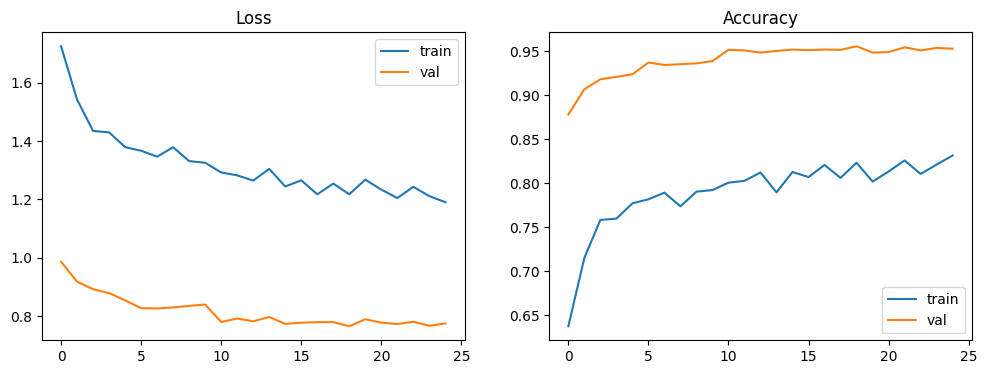

In [7]:
# 5. Training + validation loop (early stopping, best-model checkpointing)
from tqdm import tqdm

MODEL_PATH = "crop_disease_mobilenetv3_large_30_epoch.pth"
CLASSES_PATH = "class_names.json"

def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def train_model(model, criterion, optimizer, scheduler, num_epochs=30,
                use_mixup=True, alpha=0.4, patience=6):
    best_wts = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        t0 = time.time()
        lrs = [g["lr"] for g in optimizer.param_groups]
        print(f"\nEpoch {epoch+1}/{num_epochs} | LR backbone: {lrs[0]:.6f} | LR head: {lrs[1]:.6f}")

        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()
            dataloader = train_loader if phase == "train" else val_loader

            running_loss, running_corrects = 0.0, 0.0
            loop = tqdm(dataloader, desc=phase, leave=False)

            for inputs, labels in loop:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    if phase == "train" and use_mixup:
                        inputs, y_a, y_b, lam = mixup_data(inputs, labels, alpha)
                        outputs = model(inputs)
                        loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
                        preds = outputs.argmax(1)
                        running_corrects += (lam * preds.eq(y_a).sum().item()
                                             + (1 - lam) * preds.eq(y_b).sum().item())
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        preds = outputs.argmax(1)
                        running_corrects += (preds == labels).sum().item()

                    if phase == "train":
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_value)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                loop.set_postfix(loss=f"{loss.item():.4f}")

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects / len(dataloader.dataset)
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
            print(f"{phase:<5} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

            if phase == "val":
                scheduler.step(epoch_loss)
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_wts = copy.deepcopy(model.state_dict())
                    torch.save(best_wts, MODEL_PATH)
                    epochs_no_improve = 0
                    print("  ✅ Best model saved")
                else:
                    epochs_no_improve += 1

        print(f"Epoch time: {time.time() - t0:.0f}s")
        if epochs_no_improve >= patience:
            print(f"Early stopping: no val-loss improvement for {patience} epochs.")
            break

    model.load_state_dict(best_wts)
    return model, history

# ---- Train ----
model, history = train_model(model, criterion, optimizer, scheduler,
                             num_epochs=30, use_mixup=True, alpha=0.4, patience=6)

torch.save(model.state_dict(), MODEL_PATH)
with open(CLASSES_PATH, "w") as f:
    json.dump(class_names, f, indent=2)
print(f"Saved: {MODEL_PATH} and {CLASSES_PATH}")

# ---- Training curves ----
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].legend()
plt.show()

C:\Users\rahul\AppData\Local\Temp\ipykernel_12368\2043499948.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=d

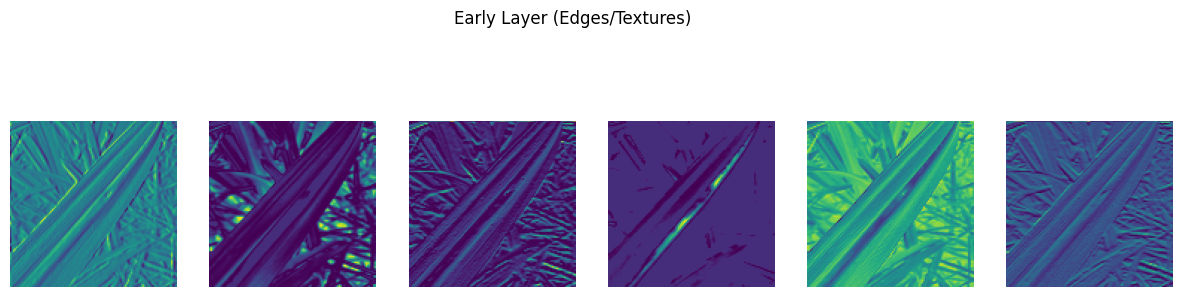

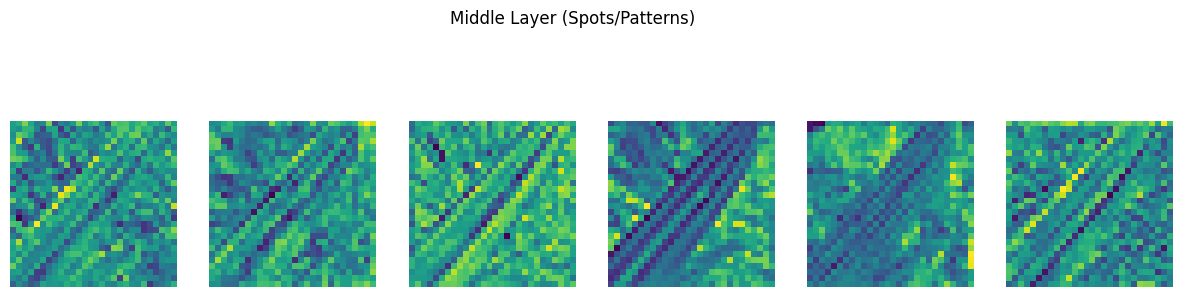

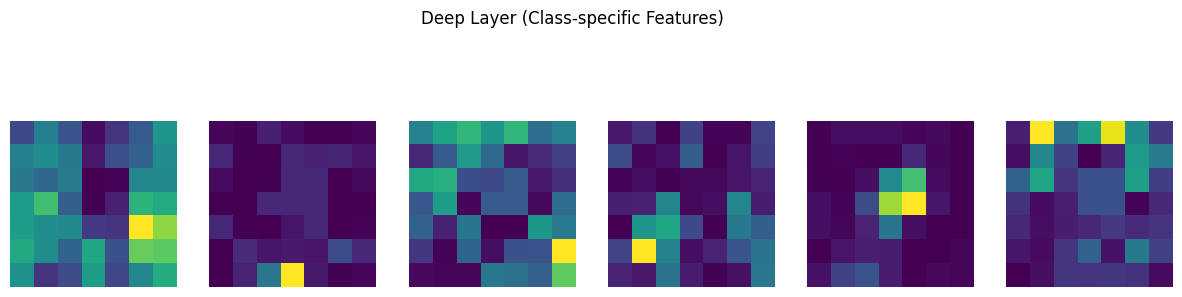

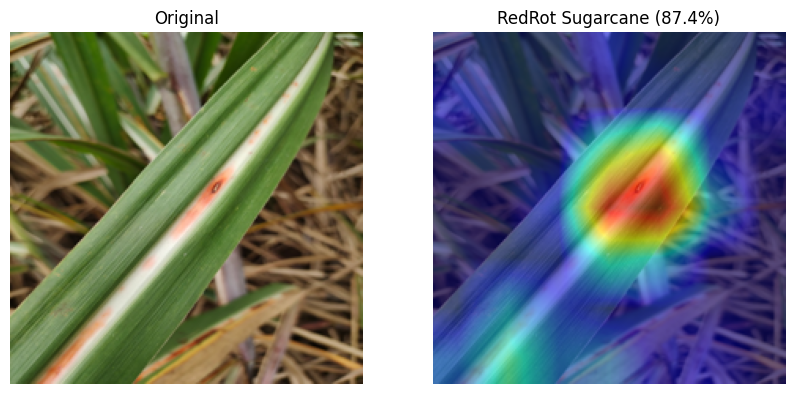

In [19]:
# 6. Feature maps + Grad-CAM
import os, cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = "crop_disease_mobilenetv3_large.pth"
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device).eval()

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

img_path = r"D:\Farm AI Dataset Final\Farm AI Dataset Final\test\RedRot Sugarcane\image386.JPG"  # <-- change this
img = Image.open(img_path).convert("RGB")
orig_np = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
input_tensor = preprocess(img).unsqueeze(0).to(device)

# ---------- Feature maps ----------
def visualize_feature_maps(model, layer_idx, input_tensor, title):
    feat_len = len(model.features)
    if layer_idx < 0:
        layer_idx = feat_len + layer_idx
    x = input_tensor.clone()
    with torch.no_grad():
        for i in range(layer_idx + 1):
            x = model.features[i](x)
    features = x.cpu().squeeze(0)

    n_show = min(6, features.shape[0])
    fig, axes = plt.subplots(1, n_show, figsize=(15, 4))
    for i in range(n_show):
        fmap = features[i].numpy()
        fmap = fmap - fmap.min()
        if fmap.max() > 0:
            fmap = fmap / fmap.max()
        axes[i].imshow(fmap, cmap="viridis")
        axes[i].axis("off")
    plt.suptitle(title)
    plt.show()

visualize_feature_maps(model, 0, input_tensor, "Early Layer (Edges/Textures)")
visualize_feature_maps(model, 4, input_tensor, "Middle Layer (Spots/Patterns)")
visualize_feature_maps(model, -1, input_tensor, "Deep Layer (Class-specific Features)")

# ---------- Grad-CAM ----------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.handle = target_layer.register_forward_hook(self._forward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()
        if out.requires_grad:                      # safe under torch.no_grad()
            out.register_hook(lambda g: setattr(self, "gradients", g.detach()))

    def remove(self):
        self.handle.remove()

    def generate(self, input_tensor, class_idx=None, gamma=0.7):
        self.model.zero_grad()
        output = self.model(input_tensor)
        probs = torch.softmax(output, dim=1)[0]
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1).squeeze(0)).cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return np.power(cam, gamma), class_idx, probs[class_idx].item()

def get_last_conv_layer(model):
    for layer in reversed(model.features):
        for sub in layer.modules():
            if isinstance(sub, torch.nn.Conv2d):
                return sub
    raise ValueError("No Conv2d layer found in model.features!")

target_layer = get_last_conv_layer(model)
gradcam = GradCAM(model, target_layer)

gc_input = input_tensor.clone().requires_grad_(True)
cam, class_idx, conf = gradcam.generate(gc_input)
gradcam.remove()   # important: removes the hook so later evaluation is not affected

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
overlay = 0.5 * heatmap + 0.5 * orig_np
overlay = overlay / overlay.max()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(orig_np); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(overlay); ax[1].set_title(f"{class_names[class_idx]} ({conf:.1%})"); ax[1].axis("off")
plt.show()

In [1]:
# 7. Load final MobileNetV3-Large model for testing (works in a fresh session too)
import json, torch, torch.nn as nn
from torchvision import models

MODEL_PATH = "crop_disease_mobilenetv3_large.pth"
CLASSES_PATH = "class_names.json"
img_height, img_width = 224, 224

with open(CLASSES_PATH) as f:
    class_names = json.load(f)
num_classes = len(class_names)

model = models.mobilenet_v3_large(weights=None)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"✅ Final MobileNetV3-Large loaded ({num_classes} classes) on {device}")

✅ Final MobileNetV3-Large loaded (25 classes) on cpu


In [40]:
# 8. Predict on a single image with confidence
import torch
from PIL import Image
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def predict_image(img_path, top_k=3):
    img = Image.open(img_path).convert("RGB")
    input_tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]

    top_probs, top_idxs = torch.topk(probs, top_k)

    print(f"\nImage: {img_path}")
    print(f"Predicted: {class_names[top_idxs[0].item()]}  ({top_probs[0].item()*100:.2f}%)")

    print(f"\nTop {top_k} predictions:")
    for prob, idx in zip(top_probs, top_idxs):
        print(f"  {class_names[idx.item()]:<40} {prob.item()*100:.2f}%")

    return class_names[top_idxs[0].item()], top_probs[0].item()

# ---- Usage ----
img_path = r"C:\Users\rahul\Downloads\images (4).jpg"  # <-- change this to your test image
predicted_class, confidence = predict_image(img_path)


Image: C:\Users\rahul\Downloads\images (4).jpg
Predicted: Earlyleafspot Groundnut  (36.00%)

Top 3 predictions:
  Earlyleafspot Groundnut                  36.00%
  Mosaic Cassava                           24.17%
  Rust Groundnut                           10.65%


In [3]:
import json, numpy as np, torch
from pathlib import Path
from collections import Counter
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# model + class_names + device come from your "Load final model" cell (run that first)
data_dir = Path(r"D:\Farm AI Dataset Final\Farm AI Dataset Final")
tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(data_dir / "train", transform=tfms)
test_ds  = datasets.ImageFolder(data_dir / "test",  transform=tfms)
assert test_ds.classes == class_names, "Class order mismatch!"

train_loader = DataLoader(train_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

@torch.no_grad()
def get_preds(loader):
    yt, yp = [], []
    for x, y in loader:
        yp.extend(model(x.to(device)).argmax(1).cpu().numpy())
        yt.extend(y.numpy())
    return np.array(yt), np.array(yp)

y_tr, p_tr = get_preds(train_loader)
y_te, p_te = get_preds(test_loader)

print(f"TRAIN accuracy: {(y_tr == p_tr).mean()*100:.2f}%")
print(f"TEST accuracy: {(y_te == p_te).mean()*100:.2f}%\n")
print(classification_report(y_te, p_te, target_names=class_names, digits=3))

errs = Counter((class_names[t], class_names[p]) for t, p in zip(y_te, p_te) if t != p)
for (t, p), n in errs.most_common(10):
    print(f"{t:>25} -> predicted as {p}: {n} times")

cm = confusion_matrix(y_te, p_te)
fig, ax = plt.subplots(figsize=(16, 16))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap="Blues", xticks_rotation=90, colorbar=False)
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\Farm AI Dataset Final\\Farm AI Dataset Final\\train'